# 2.6.1. 基本概率论

In [10]:
%matplotlib inline
import torch
from torch.distributions import multinomial
from d2l import torch as d2l
fair_probs = torch.ones([6]) / 6 # 创建一个长度为6的张量病均一化，表示掷六面骰子各面的概率均等[1/6, 1/6, ..., 1/6]
multinomial.Multinomial(1, fair_probs).sample()
# 按 fair_probs 的概率，随机抽 1 次，然后返回每个类别出现了几次

tensor([1., 0., 0., 0., 0., 0.])

In [2]:
multinomial.Multinomial(10, fair_probs).sample()

tensor([3., 0., 1., 2., 1., 3.])

In [11]:
# 将结果存储为32位浮点数以进行除法
counts = multinomial.Multinomial(1000, fair_probs).sample()
counts / 1000  # 相对频率作为估计值

tensor([0.1600, 0.1670, 0.1610, 0.1730, 0.1450, 0.1940])

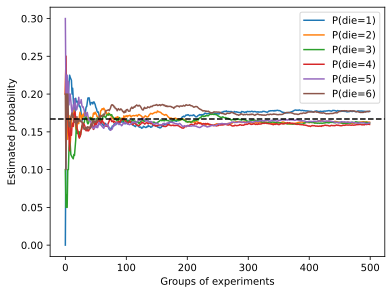

In [ ]:
counts = multinomial.Multinomial(10, fair_probs).sample((500,)) 
# 做500组实验，每组骰子丢10次，counts.shape = (500,6) 某一行可能是tensor([1., 2., 0., 3., 1., 3.])
cum_counts = counts.cumsum(dim=0) 
# 沿着第 0 维累加，也就是“把前面所有组实验的结果加起来”。cum_counts[i]表示前 i+1 组实验里，六个点数分别累计出现了多少次。
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True) # 最终形状(500, 6)
# cum_counts.sum(dim=1, keepdims=True) 表示每一行的总实验次数。 estimates[i] 表示前 i+1 组实验之后，骰子 1 到 6 的经验概率估计。

d2l.set_figsize((6, 4.5))
for i in range(6):
    d2l.plt.plot(estimates[:, i].numpy(),
                 label=("P(die=" + str(i + 1) + ")"))
# estimates[:, 0]：点数 1 的估计概率变化；estimates[:, 1]：点数 2 的估计概率变化 …… estimates[:, 5]：点数 6 的估计概率变化
d2l.plt.axhline(y=0.167, color='black', linestyle='dashed') # 画一条黑色虚线，表示真实概率：1/6 ≈ 0.167
d2l.plt.gca().set_xlabel('Groups of experiments') # get current axes 找到当前正在画的那张图的坐标轴，然后给它设置 x 轴和 y 轴标签
d2l.plt.gca().set_ylabel('Estimated probability')
d2l.plt.legend();